# 02 — Exploratory Data Analysis

Explores the coverage, quality, distribution, and temporal behavior of the raw **PETR4.SA** data collected in the previous notebook.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from statsmodels.tsa.seasonal import seasonal_decompose

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_PATH = PROJECT_ROOT / "data" / "raw" / "petr4_daily.csv"

if not RAW_PATH.exists():
    raise FileNotFoundError("Raw data not found. Run 01_data_collection.ipynb first.")

df = pd.read_csv(RAW_PATH, parse_dates=["Date"], index_col="Date").sort_index()

## Data overview

In [2]:
overview = pd.Series({
    "records": len(df),
    "start_date": df.index.min().date(),
    "end_date": df.index.max().date(),
    "duplicate_dates": int(df.index.duplicated().sum()),
    "missing_values": int(df.isna().sum().sum()),
})

display(overview.to_frame("value"))
display(df.describe().T)

,value
records,1248
start_date,2021-07-21
end_date,2026-07-21
duplicate_dates,0
missing_values,0


,count,mean,std,min,25%,50%,75%,max
Open,1248.0,3.328591e+01,5.464378e+00,2.100000e+01,2.961000e+01,3.250000e+01,3.721000e+01,5.007000e+01
High,1248.0,3.370991e+01,5.481926e+00,2.211000e+01,2.999750e+01,3.290000e+01,3.752000e+01,5.069000e+01
Low,1248.0,3.287252e+01,5.454627e+00,2.077000e+01,2.921750e+01,3.206000e+01,3.683000e+01,4.949000e+01
Close,1248.0,3.329958e+01,5.471860e+00,2.147000e+01,2.962750e+01,3.244000e+01,3.718250e+01,4.978000e+01
Adj Close,1248.0,2.345158e+01,1.003736e+01,7.518563e+00,1.373075e+01,2.653829e+01,2.994235e+01,4.852372e+01
Volume,1248.0,5.445753e+07,3.202263e+07,9.356900e+06,3.142095e+07,4.703645e+07,6.881532e+07,3.195016e+08
Dividends,1248.0,3.200936e-02,3.008347e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.732003e+00
Stock Splits,1248.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


The dataset covers five years of daily PETR4 observations and shows no missing values or duplicated dates. Price variables are internally consistent, while volume exhibits substantial dispersion and potential outliers. Since `Stock Splits` is constant, it does not add predictive information and may be excluded from the modeling dataset.

## Price, volume, returns, and volatility

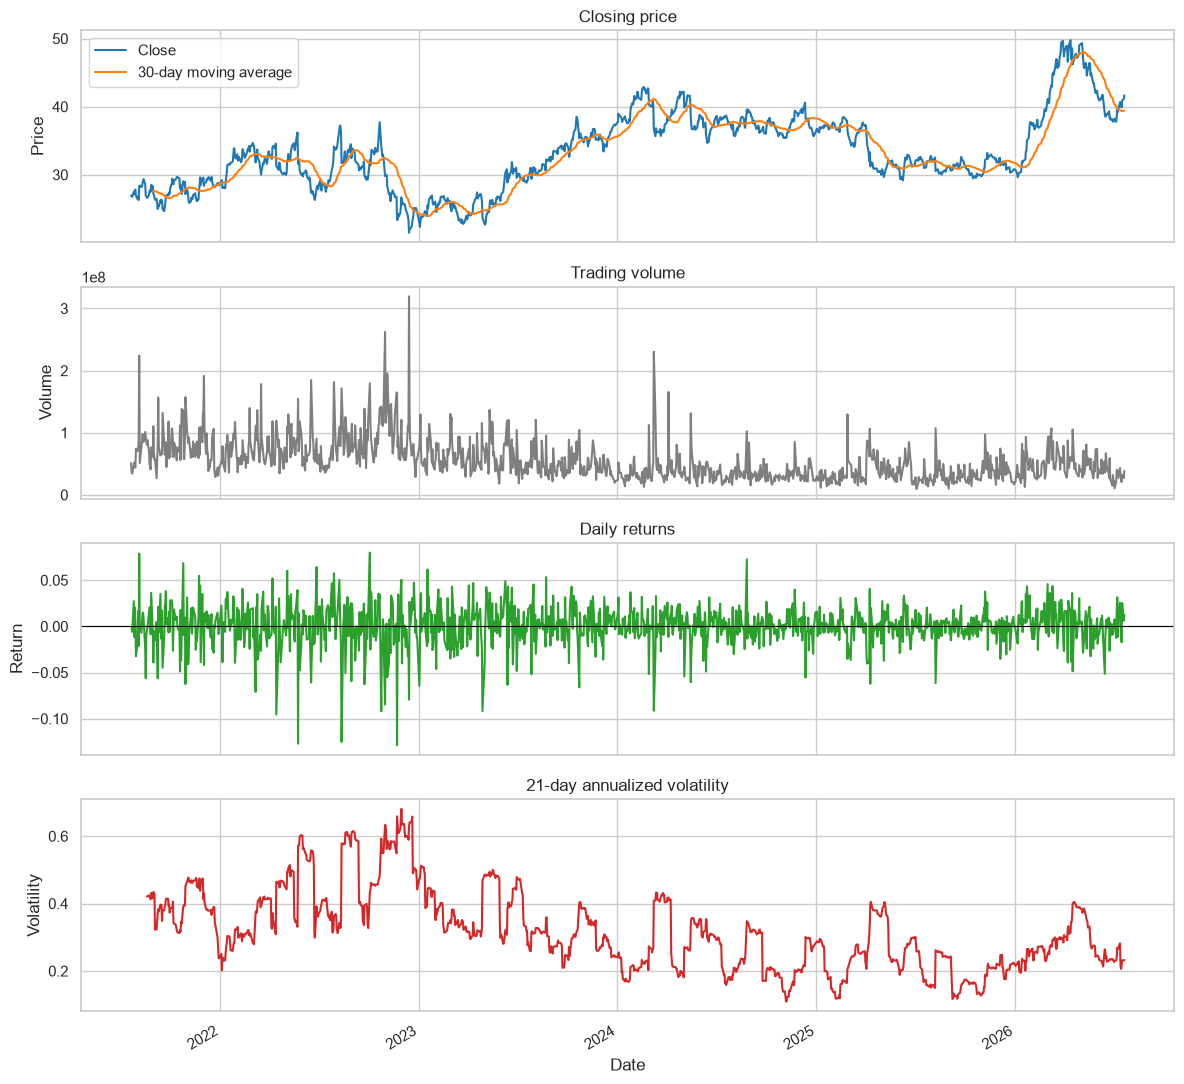

In [3]:
daily_return = df["Close"].pct_change()
rolling_mean_30 = df["Close"].rolling(30).mean()
annualized_volatility_21 = daily_return.rolling(21).std() * np.sqrt(252)

fig, axes = plt.subplots(4, 1, figsize=(12, 11), sharex=True)

df["Close"].plot(ax=axes[0], label="Close", color="tab:blue")
rolling_mean_30.plot(ax=axes[0], label="30-day moving average", color="tab:orange")
axes[0].set(title="Closing price", ylabel="Price")
axes[0].legend()

df["Volume"].plot(ax=axes[1], color="tab:gray")
axes[1].set(title="Trading volume", ylabel="Volume")

daily_return.plot(ax=axes[2], color="tab:green")
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set(title="Daily returns", ylabel="Return")

annualized_volatility_21.plot(ax=axes[3], color="tab:red")
axes[3].set(title="21-day annualized volatility", xlabel="Date", ylabel="Volatility")

plt.tight_layout()
plt.show()

The closing price exhibits distinct trend phases, including sustained appreciation, corrections, and recovery periods, indicating that the series is non-stationary. The 30-day moving average smooths short-term fluctuations and highlights the underlying market trend.

Trading volume is highly variable, with several pronounced spikes that may correspond to periods of increased market activity or relevant corporate and macroeconomic events.

Daily returns fluctuate around zero without a persistent trend, while displaying occasional large positive and negative movements, suggesting the presence of volatility clustering.

The 21-day annualized volatility is clearly time-varying, alternating between high- and low-volatility regimes rather than remaining constant throughout the sample. This behavior indicates heteroskedasticity, a common characteristic of financial time series that should be considered during the modeling stage.

## Correlation analysis

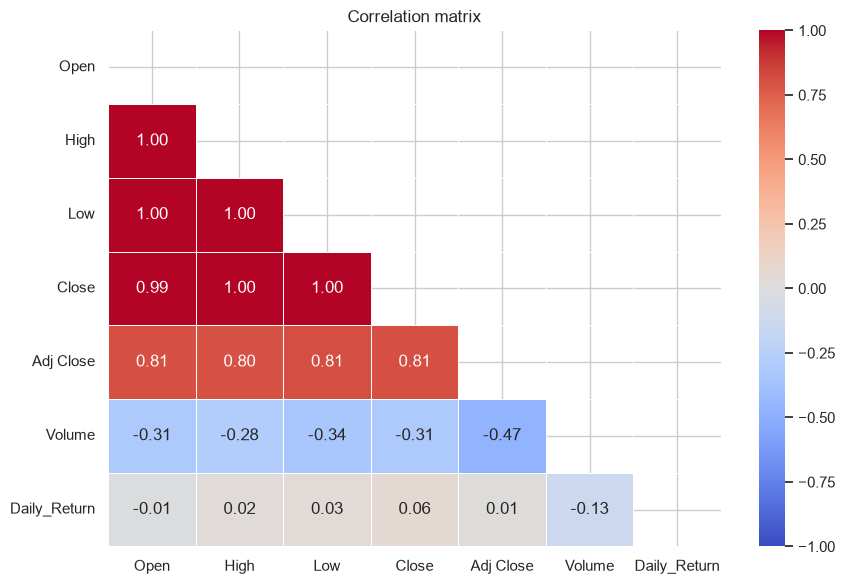

In [4]:
market_columns = [
    column for column in ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
    if column in df.columns
]
correlation_data = df[market_columns].assign(Daily_Return=daily_return)
correlation_matrix = correlation_data.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(9, 6))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

Price variables (Open, High, Low, and Close) are almost perfectly correlated, indicating strong redundancy among them. Adjusted Close remains highly correlated but reflects corporate action adjustments. Trading volume shows a moderate negative correlation with prices, whereas daily returns exhibit negligible linear correlations with the remaining variables. These relationships should be considered during feature selection to reduce multicollinearity.

## Time-series decomposition

The additive decomposition below uses **252 trading sessions** as an exploratory annual period.

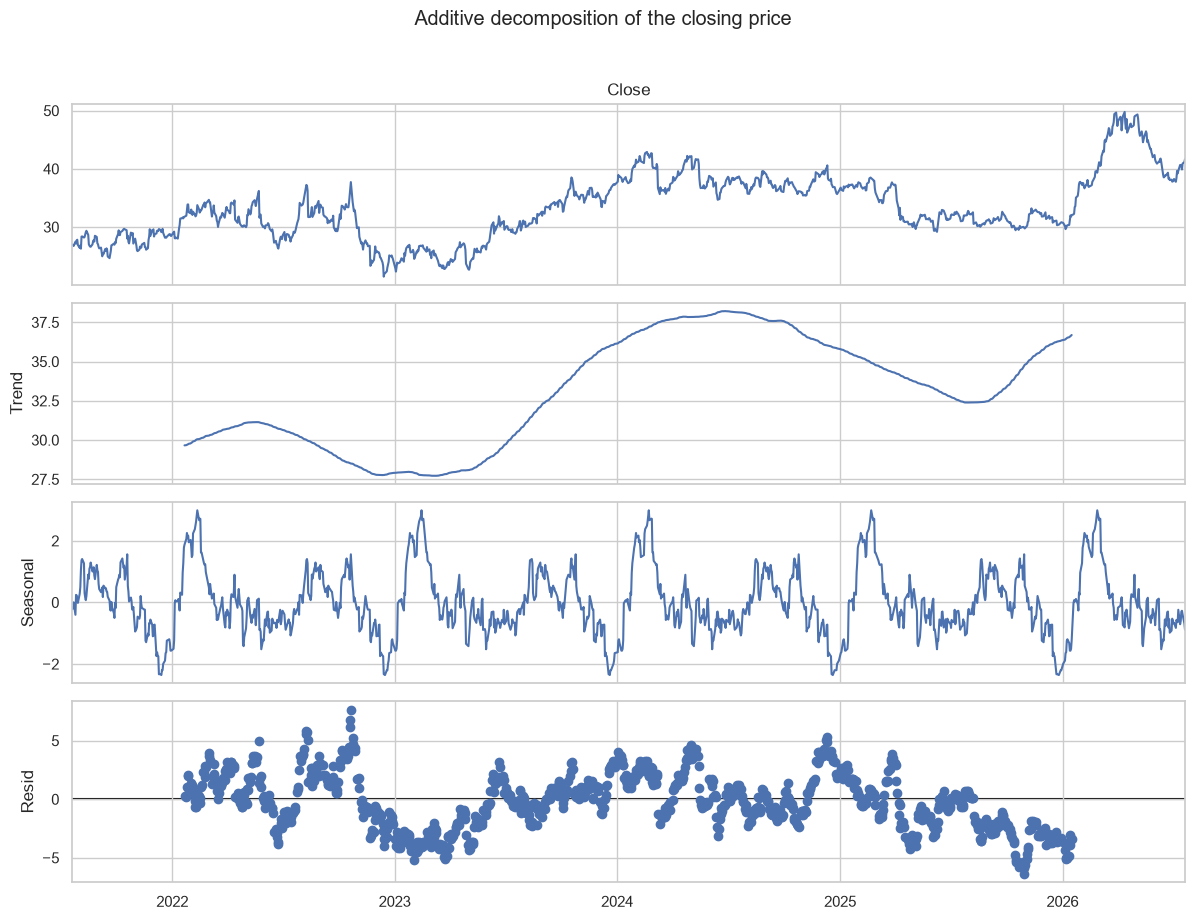

In [5]:
close = df["Close"].dropna()

if len(close) < 2 * 252:
    raise ValueError("At least 504 observations are required for annual decomposition.")

decomposition = seasonal_decompose(close, model="additive", period=252)
figure = decomposition.plot()
figure.set_size_inches(12, 9)
figure.suptitle("Additive decomposition of the closing price", y=1.02)
plt.tight_layout()
plt.show()

The additive decomposition indicates that the closing price is primarily driven by a long-term trend, with periods of sustained appreciation and decline over the sample. A recurring seasonal component is also observed, although its magnitude is relatively small compared with the overall price variation.

The residual component is centered around zero but contains periods of larger deviations, suggesting that not all fluctuations are explained by the trend and seasonal components. These remaining movements are likely associated with short-term market dynamics and external events.

Overall, the decomposition suggests that the series contains both trend and seasonal patterns, supporting the use of forecasting models capable of capturing temporal dependencies.